In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
master= pd.read_csv("../data/processed/master.csv")

In [3]:
drop_cols = [
    "Name_rat",
    "NSE Code_rat",
    "Industry_rat",
    "Days Receivable Outstanding",
    "signal"
]

for col in drop_cols:
    if col in master.columns:
        master.drop(columns=col, inplace=True)

for col in ["t_1_price"]:
    if col in master.columns:
        master.drop(columns=col, inplace=True)

In [4]:
master["future_return"].isnull().sum()

np.int64(1)

In [5]:
master = master[
    master["future_return"].notna()
]

In [6]:
master["future_return"].isnull().sum()

np.int64(0)

In [7]:
master.select_dtypes(include="object").columns.tolist()

/tmp/ipykernel_946/2313172988.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  master.select_dtypes(include="object").columns.tolist()


['Name_bal', 'NSE Code_bal', 'Industry_bal', 'join_key']

In [8]:
master = master.drop(
    columns=[
        "Name_bal",
        "BSE Code_bal",
        "NSE Code_bal"
    ],
    errors="ignore"
)

In [9]:
X = master.drop(
    columns=["future_return"]
)

y = master["future_return"]

In [10]:
X.shape

(4667, 93)

In [11]:
X.columns.tolist()[-20:]

['Return on invested capital',
 'Debtor days',
 'Industry PBV',
 'Credit rating',
 'Working Capital Days',
 'Earning Power',
 'Graham Number',
 'Cash Conversion Cycle',
 'Days Payable Outstanding',
 'Days Inventory Outstanding',
 'Public holding',
 'FII holding',
 'Change in FII holding',
 'Change in DII holding',
 'DII holding',
 'Book value preceding year',
 'Return on capital employed preceding year',
 'Return on assets preceding year',
 'Return on equity preceding year',
 'Number of Shareholders preceding quarter']

In [12]:
X.columns.tolist()[:20]

['Industry_bal',
 'Current Price_bal',
 'Debt',
 'Equity capital',
 'Preference capital',
 'Reserves',
 'Secured loan',
 'Unsecured loan',
 'Balance sheet total',
 'Gross block',
 'Revaluation reserve',
 'Accumulated depreciation',
 'Net block',
 'Capital work in progress',
 'Investments',
 'Current assets',
 'Current liabilities',
 'Book value of unquoted investments',
 'Market value of quoted investments',
 'Contingent liabilities']

In [13]:
master.columns[
    master.columns.str.contains(
        "signal|future|t_1|price",
        case=False,
        regex=True
    )
]

Index(['Current Price_bal', 'Current Price_rat', 'Price to Earning',
       'Price to book value', 'future_return'],
      dtype='str')

In [14]:
X.isnull().mean().sort_values(ascending=False).head(20)

Credit rating                      1.000000
Days Payable Outstanding           0.357189
Days Inventory Outstanding         0.304907
Debt 10Years back                  0.286051
Working capital 10Years back       0.286051
Graham Number                      0.262053
Inventory turnover ratio           0.250054
Price to Earning                   0.223055
Net block 7Years back              0.202271
Debt 7Years back                   0.202271
Working capital 7Years back        0.202271
Working capital 5Years back        0.124277
Debt 5Years back                   0.124277
Net block 5Years back              0.124277
Return on equity preceding year    0.110992
Price to book value                0.105635
Book value preceding year          0.094493
Return on equity                   0.093208
Exports percentage                 0.081208
Debt to equity                     0.076709
dtype: float64

In [15]:
X = X.drop(columns=["Credit rating"], errors="ignore")

In [16]:
[col for col in X.columns if col.endswith("_rat")]

['BSE Code_rat', 'Current Price_rat', 'Market Capitalization_rat']

In [17]:
[col for col in X.columns if col.endswith("_bal")]

['Industry_bal', 'Current Price_bal', 'Market Capitalization_bal']

In [18]:
X = X.drop(
    columns=[
        "BSE Code_rat"
    ],
    errors="ignore"
)

In [19]:
X.shape

(4667, 91)

In [20]:
[
    col for col in X.columns
    if col.endswith("_rat")
]

['Current Price_rat', 'Market Capitalization_rat']

In [21]:
X = X.drop(
    columns=[
        "Current Price_rat",
        "Market Capitalization_rat"
    ],
    errors="ignore"
)

In [22]:
[col for col in X.columns if "signal" in col.lower()]

[]

In [23]:
[col for col in X.columns if "future" in col.lower()]

[]

In [24]:
[col for col in X.columns if "t_1" in col.lower()]

[]

In [25]:
[col for col in X.columns if "price" in col.lower()]

['Current Price_bal', 'Price to Earning', 'Price to book value']

In [26]:
[col for col in X.columns if col.endswith("_rat")]

[]

In [27]:
[col for col in X.columns if col.endswith("_bal")]

['Industry_bal', 'Current Price_bal', 'Market Capitalization_bal']

In [28]:
X = X.rename(columns={
    "Industry_bal": "Industry",
    "Current Price_bal": "Current Price",
    "Market Capitalization_bal": "Market Capitalization"
})

In [29]:
X.shape


(4667, 89)

In [30]:
X = X.drop(columns=["join_key"], errors="ignore")

In [31]:
cat_cols = X.select_dtypes(include="object").columns

num_cols = X.select_dtypes(
    include=["int64","float64"]
).columns

print(cat_cols)
print(len(num_cols))

Index(['Industry'], dtype='str')
87


/tmp/ipykernel_946/4278791258.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [33]:
cat_cols = X_train.select_dtypes(
    include="object"
).columns

num_cols = X_train.select_dtypes(
    include=["int64","float64"]
).columns

print(cat_cols)
print(len(num_cols))

Index(['Industry'], dtype='str')
87


/tmp/ipykernel_946/1795231725.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_pipe = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

cat_pipe = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [36]:
rf_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](88,)","['Industry','Current Price','Debt',...,'Return on assets preceding year', 'Return on equity preceding year', 'Number of Shareholders preceding quarter']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,88
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in

In [37]:
y_pred_rf = rf_model.predict(X_test)

In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = mse_rf ** 0.5

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

MAE : 0.04541033081828668
RMSE: 0.05755905733462159
R2  : 0.35963054650271686


In [39]:
n = X_test.shape[0]
p = X_train.shape[1]

adj_r2_rf = (
    1 -
    (1-r2_rf)*(n-1)/(n-p-1)
)

adj_r2_rf

0.29294118329826613

In [40]:
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lr_model.fit(X_train, y_train)

pred_lr = lr_model.predict(X_test)

r2_lr = r2_score(y_test, pred_lr)

r2_lr

-0.09977054266959717

In [41]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

In [42]:
num_pipe_knn = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe_knn = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_knn = ColumnTransformer([
    ("num", num_pipe_knn, num_cols),
    ("cat", cat_pipe_knn, cat_cols)
])

knn_model = Pipeline([
    ("preprocessor", preprocessor_knn),
    ("regressor", KNeighborsRegressor(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

pred_knn = knn_model.predict(X_test)

r2_knn = r2_score(y_test, pred_knn)

r2_knn

0.015627502170056595

In [43]:
from sklearn.ensemble import ExtraTreesRegressor

et_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "regressor",
        ExtraTreesRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

et_model.fit(X_train, y_train)

pred_et = et_model.predict(X_test)

r2_et = r2_score(y_test, pred_et)

r2_et

0.3139105957059599

In [44]:
from xgboost import XGBRegressor

In [45]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "regressor",
        XGBRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

xgb_model.fit(X_train, y_train)

pred_xgb = xgb_model.predict(X_test)

r2_xgb = r2_score(y_test, pred_xgb)

r2_xgb

0.3252905664466005

In [46]:
from catboost import CatBoostRegressor

In [47]:
cat_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "regressor",
        CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_state=42,
            verbose=0
        )
    )
])

cat_model.fit(X_train, y_train)

pred_cat = cat_model.predict(X_test)

r2_cat = r2_score(y_test, pred_cat)

r2_cat

0.3990750068043598

In [48]:
pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN",
        "Random Forest",
        "Extra Trees",
        "XGBoost",
        "CatBoost"
    ],
    "R2": [
        r2_lr,
        r2_knn,
        r2_rf,
        r2_et,
        r2_xgb,
        r2_cat
    ]
}).sort_values(
    "R2",
    ascending=False
)

,Model,R2
5,CatBoost,0.399075
2,Random Forest,0.359631
4,XGBoost,0.325291
3,Extra Trees,0.313911
1,KNN,0.015628
0,Linear Regression,-0.099771


In [49]:
from sklearn.model_selection import cross_val_score

cat_cv = cross_val_score(
    cat_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print(cat_cv)
print("Mean CV R2:", cat_cv.mean())
print("Std CV:", cat_cv.std())

[0.41949852 0.40036719 0.38422759 0.36883488 0.35108876]
Mean CV R2: 0.3848033875573125
Std CV: 0.023824295332057023


In [50]:
from sklearn.impute import KNNImputer

num_pipe_knn_imp = Pipeline([
    (
        "imputer",
        KNNImputer(n_neighbors=5)
    )
])

preprocessor_knn_imp = ColumnTransformer([
    ("num", num_pipe_knn_imp, num_cols),
    ("cat", cat_pipe, cat_cols)
])

In [51]:
cat_pipe_knn = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor_knn = ColumnTransformer([
    ("num", num_pipe_knn, num_cols),
    ("cat", cat_pipe_knn, cat_cols)
])

cat_knn = Pipeline([
    ("preprocessor", preprocessor_knn),
    (
        "regressor",
        CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_state=42,
            verbose=0
        )
    )
])

cat_knn.fit(X_train, y_train)

pred_knn_imp = cat_knn.predict(X_test)

r2_knn_imp = r2_score(
    y_test,
    pred_knn_imp
)

print(r2_knn_imp)

0.3991141453326341


In [52]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [53]:
num_pipe_iter = Pipeline([
    (
        "imputer",
        IterativeImputer(
            random_state=42,
            max_iter=10
        )
    )
])

preprocessor_iter = ColumnTransformer([
    ("num", num_pipe_iter, num_cols),
    ("cat", cat_pipe_knn, cat_cols)
])

cat_iter = Pipeline([
    ("preprocessor", preprocessor_iter),
    (
        "regressor",
        CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_state=42,
            verbose=0
        )
    )
])

cat_iter.fit(X_train, y_train)

pred_iter = cat_iter.predict(X_test)

r2_iter = r2_score(
    y_test,
    pred_iter
)

print(r2_iter)

/home/ridhi/bigdata-env/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


0.39762706581739016


In [54]:
pd.DataFrame({
    "Imputer":[
        "Median",
        "KNN",
        "Iterative"
    ],
    "R2":[
        r2_cat,
        r2_knn_imp,
        r2_iter
    ]
}).sort_values(
    "R2",
    ascending=False
)

,Imputer,R2
1,KNN,0.399114
0,Median,0.399075
2,Iterative,0.397627


In [55]:
feature_names = (
    cat_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    cat_model
    .named_steps["regressor"]
    .feature_importances_
)

fi_cat = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

fi_cat = fi_cat.sort_values(
    "importance",
    ascending=False
)

fi_cat.head(30)

,feature,importance
49,num__Return on assets,7.628663
46,num__Price to Earning,7.204829
50,num__Debt to equity,6.496713
47,num__Dividend yield,3.797976
51,num__Return on equity,3.619463
79,num__Change in FII holding,3.282067
63,num__G Factor,2.699593
0,num__Current Price,2.640582
66,num__Number of Shareholders,2.255433
73,num__Graham Number,2.148024


In [56]:
fi_cat["cumulative_importance"] = (
    fi_cat["importance"].cumsum()
)

fi_cat.head(30)

,feature,importance,cumulative_importance
49,num__Return on assets,7.628663,7.628663
46,num__Price to Earning,7.204829,14.833492
50,num__Debt to equity,6.496713,21.330205
47,num__Dividend yield,3.797976,25.128181
51,num__Return on equity,3.619463,28.747644
79,num__Change in FII holding,3.282067,32.029711
63,num__G Factor,2.699593,34.729304
0,num__Current Price,2.640582,37.369886
66,num__Number of Shareholders,2.255433,39.625319
73,num__Graham Number,2.148024,41.773343


In [57]:
top80 = fi_cat[
    fi_cat["cumulative_importance"] <= 80
]

top80.shape

(44, 3)

In [58]:
top80.head(44)

,feature,importance,cumulative_importance
49,num__Return on assets,7.628663,7.628663
46,num__Price to Earning,7.204829,14.833492
50,num__Debt to equity,6.496713,21.330205
47,num__Dividend yield,3.797976,25.128181
51,num__Return on equity,3.619463,28.747644
79,num__Change in FII holding,3.282067,32.029711
63,num__G Factor,2.699593,34.729304
0,num__Current Price,2.640582,37.369886
66,num__Number of Shareholders,2.255433,39.625319
73,num__Graham Number,2.148024,41.773343


In [59]:
top_features = (
    top80["feature"]
    .tolist()
)

len(top_features)

44

In [60]:
top_features_original = [
    col.replace("num__", "")
       .replace("cat__", "")
    for col in top_features
]

top_features_original[:20]

['Return on assets',
 'Price to Earning',
 'Debt to equity',
 'Dividend yield',
 'Return on equity',
 'Change in FII holding',
 'G Factor',
 'Current Price',
 'Number of Shareholders',
 'Graham Number',
 'Earnings yield',
 'Return on capital employed preceding year',
 'Return on invested capital',
 'Price to book value',
 'Debtor days',
 'Quick ratio',
 'Return on assets preceding year',
 'Earning Power',
 'Book value preceding year',
 'Number of Shareholders preceding quarter']

In [61]:
missing = [
    col
    for col in top_features_original
    if col not in X.columns
]

len(missing), missing[:10]

(0, [])

In [62]:
selected_features = [
    col
    for col in top_features_original
    if col in X.columns
]

X_reduced = X[selected_features]

X_reduced.shape

(4667, 44)

In [63]:
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
cat_cols_fs = X_reduced.select_dtypes(
    include="object"
).columns

num_cols_fs = X_reduced.select_dtypes(
    include=["int64", "float64"]
).columns

In [65]:
preprocessor_fs = ColumnTransformer([
    (
        "num",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            )
        ]),
        num_cols_fs
    ),
    (
        "cat",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]),
        cat_cols_fs
    )
])

In [66]:
cat_fs = Pipeline([
    ("preprocessor", preprocessor_fs),
    (
        "regressor",
        CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_state=42,
            verbose=0
        )
    )
])

In [67]:
cat_fs.fit(
    X_train_fs,
    y_train_fs
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](0,)",[]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['Return on assets','Price to Earning','Debt to equity',..., 'Return on equity preceding year','Days Inventory Outstanding', 'Current assets']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. 

In [68]:
pred_fs = cat_fs.predict(
    X_test_fs
)

r2_fs = r2_score(
    y_test_fs,
    pred_fs
)

print(r2_fs)

0.4022120642710535


In [69]:
top20_features = (
    fi_cat.head(20)["feature"]
    .str.replace("num__", "")
    .str.replace("cat__", "")
    .tolist()
)

top20_features = [
    c for c in top20_features
    if c in X.columns
]

len(top20_features)

20

In [70]:
X_top20 = X[top20_features]

X_top20.shape

(4667, 20)

In [71]:
from sklearn.model_selection import train_test_split

X_train_20, X_test_20, y_train_20, y_test_20 = train_test_split(
    X_top20,
    y,
    test_size=0.20,
    random_state=42
)

In [72]:
cat_cols_20 = X_top20.select_dtypes(
    include="object"
).columns

num_cols_20 = X_top20.select_dtypes(
    include=["int64", "float64"]
).columns

In [73]:
preprocessor_20 = ColumnTransformer([
    (
        "num",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            )
        ]),
        num_cols_20
    ),
    (
        "cat",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "encoder",
                OneHotEncoder(handle_unknown="ignore")
            )
        ]),
        cat_cols_20
    )
])

In [74]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

cat_20 = Pipeline([
    ("preprocessor", preprocessor_20),
    (
        "regressor",
        CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_state=42,
            verbose=0
        )
    )
])

In [75]:
cat_20.fit(
    X_train_20,
    y_train_20
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](0,)",[]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Return on assets','Price to Earning','Debt to equity',..., 'Earning Power','Book value preceding year', 'Number of Shareholders preceding quarter']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dr

In [76]:
pred_20 = cat_20.predict(
    X_test_20
)

r2_20 = r2_score(
    y_test_20,
    pred_20
)

print("Top 20 R2:", r2_20)

Top 20 R2: 0.39843626199142423


In [77]:
pd.DataFrame({
    "Feature_Set":[
        "All Features",
        "Top 44",
        "Top 20"
    ],
    "R2":[
        r2_cat,
        r2_fs,
        r2_20
    ]
}).sort_values(
    "R2",
    ascending=False
)

,Feature_Set,R2
1,Top 44,0.402212
0,All Features,0.399075
2,Top 20,0.398436


In [78]:
! pip install optuna

In [79]:
from sklearn.pipeline import Pipeline

from catboost import CatBoostRegressor

from sklearn.model_selection import cross_val_score

import optuna

In [80]:


from catboost import CatBoostRegressor

from sklearn.metrics import r2_score

In [81]:
def objective(trial):

    params = {

        "iterations": trial.suggest_int(
            "iterations",
            200,
            1200
        ),

        "depth": trial.suggest_int(
            "depth",
            3,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.30,
            log=True
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1,
            20
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0,
            10
        ),

        "loss_function": "RMSE",

        "verbose": 0,

        "random_state": 42
    }

    model = Pipeline([
        ("preprocessor", preprocessor_fs),
        (
            "regressor",
            CatBoostRegressor(**params)
        )
    ])

    scores = cross_val_score(
        model,
        X_reduced,
        y,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    return scores.mean()

In [82]:
study = optuna.create_study(
    direction="maximize"
)

[I 2026-06-20 14:58:13,028] A new study created in memory with name: no-name-971c8d50-623c-4f3a-bd79-72d82e0d796f


In [83]:
# study.optimize(
    #objective,
    #n_trials=5
#)

In [85]:
#print(
    #"Best CV R2:",
   # study.best_value
#)

##print(
    #study.best_params
#)

In [ ]:
best_params = study.best_params

final_cat = Pipeline([
    ("preprocessor", preprocessor_fs),
    (
        "regressor",
        CatBoostRegressor(
            **best_params,
            verbose=0,
            random_state=42
        )
    )
])

In [ ]:
final_cat.fit(
    X_train_fs,
    y_train_fs
)

In [ ]:
from sklearn.metrics import r2_score

pred_final = final_cat.predict(
    X_test_fs
)

final_r2 = r2_score(
    y_test_fs,
    pred_final
)

print(final_r2)

## Hyperparameter Tuning (Optuna)

Optuna was used to explore CatBoost hyperparameters including iterations, depth, learning rate, l2_leaf_reg, and random_strength.

Due to computational constraints, a limited number of trials were executed. The tuned configurations did not outperform the feature selected CatBoost model (R² ≈ 0.402), which remained the best performing approach.

# Model Comparison

In [86]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN",
        "Extra Trees",
        "XGBoost",
        "Random Forest",
        "CatBoost",
        "CatBoost (Top 44 Features)"
    ],
    "R2": [
        r2_lr,
        r2_knn,
        r2_et,
        r2_xgb,
        r2_rf,
        r2_cat,
        r2_fs
    ]
})

results.sort_values("R2", ascending=False)

,Model,R2
6,CatBoost (Top 44 Features),0.402212
5,CatBoost,0.399075
4,Random Forest,0.359631
3,XGBoost,0.325291
2,Extra Trees,0.313911
1,KNN,0.015628
0,Linear Regression,-0.099771


CatBoost performed best.
Feature selection improved performance.
KNN imputation slightly outperformed Iterative Imputation.
Fundamental quality and ownership features were among the strongest predictors.

# Feature Selection Results

In [88]:
fs_results = pd.DataFrame({
    "Feature Set": [
        "All Features",
        "Top 44 Features",
        "Top 20 Features"
    ],
    "R2": [
        r2_cat,
        r2_fs,
        r2_20
    ]
})

fs_results.sort_values(
    "R2",
    ascending=False
)

,Feature Set,R2
1,Top 44 Features,0.402212
0,All Features,0.399075
2,Top 20 Features,0.398436



### Feature Selection Insights

Feature importance-based selection improved model performance.

Reducing the feature space from all features to the top 44 features increased R² from approximately 0.399 to 0.402.

Further reducing the feature set to the top 20 features resulted in a slight decline in performance, indicating that some predictive information was lost.

The Top 44 feature configuration was therefore selected as the final model.

# Cross Validation Result


In [89]:
cat_cv.mean(), cat_cv.std()

(np.float64(0.3848033875573125), np.float64(0.023824295332057023))

In [90]:
cv_summary = pd.DataFrame({
    "Metric": ["Mean CV R²", "Std CV"],
    "Value": [
        cat_cv.mean(),
        cat_cv.std()
    ]
})

cv_summary

,Metric,Value
0,Mean CV R²,0.384803
1,Std CV,0.023824


### Cross Validation Results

Five fold cross validation was performed to evaluate model stability and generalization.

The CatBoost model achieved a mean cross-validation R² score of approximately 0.385 with a standard deviation of 0.024, indicating relatively consistent performance across folds.

# Feature Selection Results


In [98]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": cat_fs.named_steps["regressor"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
2,num__Debt to equity,7.817026
1,num__Price to Earning,7.334849
0,num__Return on assets,6.201018
4,num__Return on equity,4.759895
3,num__Dividend yield,4.427986
5,num__Change in FII holding,3.740034
6,num__G Factor,3.106603
8,num__Number of Shareholders,2.943863
7,num__Current Price,2.834050
14,num__Debtor days,2.465263


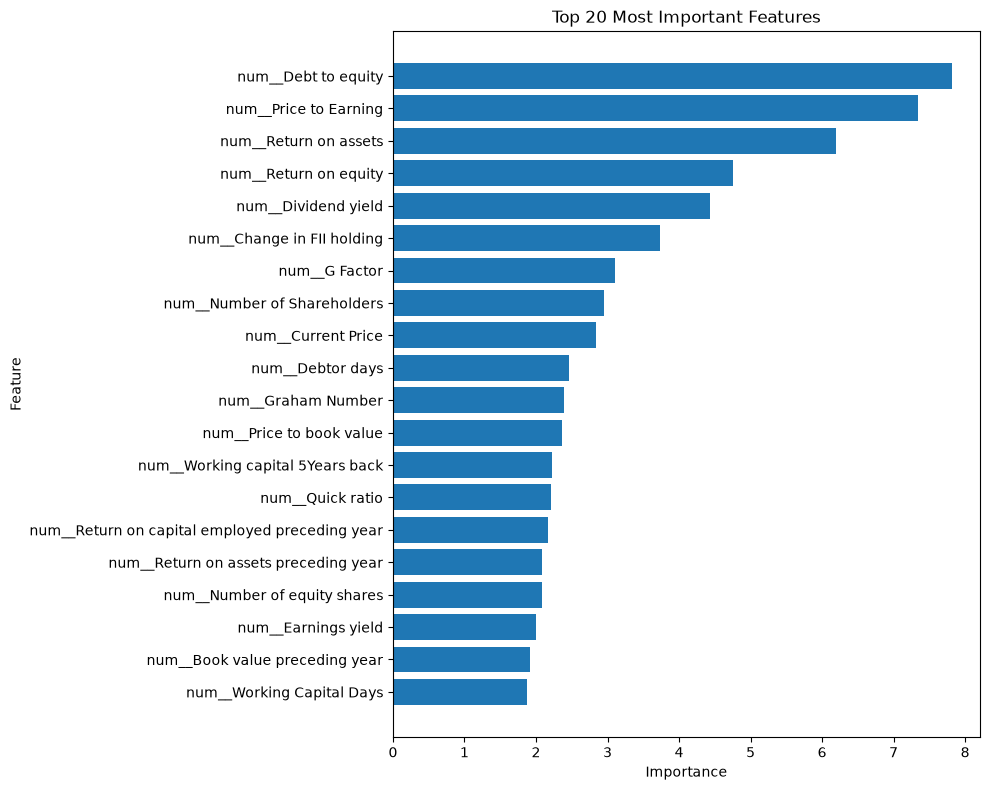

In [99]:
plt.figure(figsize=(10,8))

top20 = feature_importance.head(20)

plt.barh(
    top20["Feature"][::-1],
    top20["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features")

plt.tight_layout()
plt.show()

### Feature Importance Insights

The most influential variables were valuation, profitability, ownership, and leverage-related metrics.

Debt to equity ratio, price-to-earnings ratio, return on assets, return on equity, dividend yield, and changes in FII holdings emerged as the strongest predictors of future stock returns.

These results suggest that both company fundamentals and investor participation play an important role in explaining subsequent performance.

In [100]:
import joblib

joblib.dump(
    cat_fs,
    "../models/stock_return_model.pkl"
)

['../models/stock_return_model.pkl']

In [101]:
import os

os.path.exists("../models/stock_return_model.pkl")

True

In [102]:
loaded_model = joblib.load(
    "../models/stock_return_model.pkl"
)

type(loaded_model)

sklearn.pipeline.Pipeline

In [105]:
 X_reduced.columns.tolist()


['Return on assets',
 'Price to Earning',
 'Debt to equity',
 'Dividend yield',
 'Return on equity',
 'Change in FII holding',
 'G Factor',
 'Current Price',
 'Number of Shareholders',
 'Graham Number',
 'Earnings yield',
 'Return on capital employed preceding year',
 'Return on invested capital',
 'Price to book value',
 'Debtor days',
 'Quick ratio',
 'Return on assets preceding year',
 'Earning Power',
 'Book value preceding year',
 'Number of Shareholders preceding quarter',
 'Working capital 5Years back',
 'Number of equity shares',
 'Asset Turnover Ratio',
 'Equity capital',
 'Debt 3Years back',
 'Working Capital Days',
 'Unpledged promoter holding',
 'Net block 5Years back',
 'Debt',
 'Industry PE',
 'Piotroski score',
 'Inventory',
 'Book value',
 'Financial leverage',
 'Working capital preceding year',
 'Promoter holding',
 'Working capital 10Years back',
 'Cash Conversion Cycle',
 'Net block 7Years back',
 'Secured loan',
 'Debt 10Years back',
 'Return on equity preceding yea

In [106]:
feature_importance.head(15)

,Feature,Importance
2,num__Debt to equity,7.817026
1,num__Price to Earning,7.334849
0,num__Return on assets,6.201018
4,num__Return on equity,4.759895
3,num__Dividend yield,4.427986
5,num__Change in FII holding,3.740034
6,num__G Factor,3.106603
8,num__Number of Shareholders,2.943863
7,num__Current Price,2.834050
14,num__Debtor days,2.465263


In [107]:
top15_features = [
    "Debt to equity",
    "Price to Earning",
    "Return on assets",
    "Return on equity",
    "Dividend yield",
    "Change in FII holding",
    "G Factor",
    "Number of Shareholders",
    "Current Price",
    "Debtor days",
    "Graham Number",
    "Price to book value",
    "Working capital 5Years back",
    "Quick ratio",
    "Return on capital employed preceding year"
]

In [108]:
X_top15 = X[top15_features]

X_train_15, X_test_15, y_train_15, y_test_15 = train_test_split(
    X_top15,
    y,
    test_size=0.2,
    random_state=42
)

In [109]:
cat_cols_15 = X_train_15.select_dtypes(
    include="object"
).columns.tolist()

num_cols_15 = X_train_15.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical:", cat_cols_15)
print("Numerical:", len(num_cols_15))

Categorical: []
Numerical: 15


In [110]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer

num_pipe_15 = Pipeline([
    (
        "imputer",
        KNNImputer(n_neighbors=5)
    )
])

preprocessor_15 = ColumnTransformer([
    (
        "num",
        num_pipe_15,
        num_cols_15
    )
])

In [111]:
from catboost import CatBoostRegressor

cat_15 = Pipeline([
    (
        "preprocessor",
        preprocessor_15
    ),
    (
        "regressor",
        CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_state=42,
            verbose=0
        )
    )
])

cat_15.fit(
    X_train_15,
    y_train_15
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](0,)",[]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Debt to equity','Price to Earning','Return on assets',..., 'Working capital 5Years back','Quick ratio', 'Return on capital employed preceding year']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (defau

In [112]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

pred_15 = cat_15.predict(
    X_test_15
)

r2_15 = r2_score(
    y_test_15,
    pred_15
)

mae_15 = mean_absolute_error(
    y_test_15,
    pred_15
)

rmse_15 = root_mean_squared_error(
    y_test_15,
    pred_15
)

print("MAE :", mae_15)
print("RMSE:", rmse_15)
print("R2  :", r2_15)

MAE : 0.04456477801847238
RMSE: 0.05656685526408674
R2  : 0.3815176178784968


In [113]:
from sklearn.model_selection import cross_val_score

cv_15 = cross_val_score(
    cat_15,
    X_top15,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("CV Scores:", cv_15)
print("Mean CV R2:", cv_15.mean())
print("Std CV:", cv_15.std())

CV Scores: [0.39848933 0.36315654 0.36946506 0.35544501 0.34480146]
Mean CV R2: 0.3662714795906216
Std CV: 0.018089037549325837


In [114]:
comparison = pd.DataFrame({
    "Model": [
        "All Features",
        "Top 44 Features",
        "Top 20 Features",
        "Top 15 Features"
    ],
    "R2": [
        r2_cat,
        r2_fs,
        r2_20,
        r2_15
    ]
})

comparison.sort_values(
    "R2",
    ascending=False
)

,Model,R2
1,Top 44 Features,0.402212
0,All Features,0.399075
2,Top 20 Features,0.398436
3,Top 15 Features,0.381518


In [115]:
import joblib

joblib.dump(
    cat_15,
    "../models/stock_return_app_model.pkl"
)

['../models/stock_return_app_model.pkl']